# Experiment A-4


Training Perceptron...
Epoch 1: errors = 2
Epoch 2: errors = 3
Epoch 3: errors = 2
Epoch 4: errors = 0


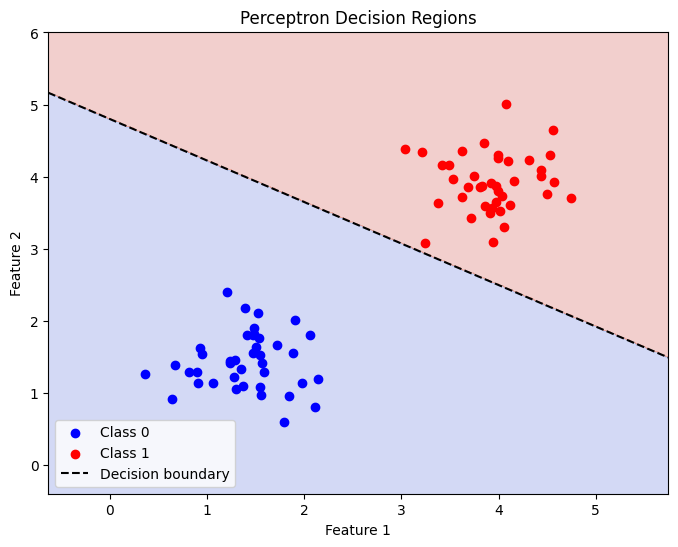

In [1]:
"""A-4: Demonstrate perceptron learning law and decision regions graphically."""

import numpy as np
import matplotlib.pyplot as plt

# 1. Generate data
rng = np.random.default_rng(7)
class0 = rng.normal(loc=[1.5, 1.5], scale=0.45, size=(40, 2))
class1 = rng.normal(loc=[4.0, 4.0], scale=0.45, size=(40, 2))
X = np.vstack([class0, class1])
y = np.array([0] * 40 + [1] * 40)

# 2. Perceptron Learning Law
w = np.zeros(2)
b = 0.0
lr = 0.1

print("Training Perceptron...")
for epoch in range(10):
    errors = 0
    for i in range(len(X)):
        # Predict
        y_hat = 1 if np.dot(w, X[i]) + b >= 0 else 0
        # Update weights and bias
        update = lr * (y[i] - y_hat)
        w += update * X[i]
        b += update
        if update != 0:
            errors += 1
    print(f"Epoch {epoch + 1}: errors = {errors}")
    if errors == 0:
        break

# 3. Plot Decision Regions
x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 300), np.linspace(y_min, y_max, 300))

# Predict for each point on the grid
grid = np.c_[xx.ravel(), yy.ravel()]
Z = np.array([1 if np.dot(w, p) + b >= 0 else 0 for p in grid]).reshape(xx.shape)

# Plotting
plt.figure(figsize=(8, 6))
plt.contourf(xx, yy, Z, alpha=0.25, cmap="coolwarm")
plt.scatter(class0[:, 0], class0[:, 1], c="blue", label="Class 0")
plt.scatter(class1[:, 0], class1[:, 1], c="red", label="Class 1")

# Draw boundary line
line_x = np.array([x_min, x_max])
line_y = -(w[0] * line_x + b) / w[1]
plt.plot(line_x, line_y, "k--", label="Decision boundary")

plt.title("Perceptron Decision Regions")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.legend()
plt.show()


In [2]:
X

array([[1.50055357, 1.63443549],
       [1.37663797, 1.09923367],
       [1.29539815, 1.05375905],
       [1.52706462, 2.10309686],
       [1.27850707, 1.2207863 ],
       [1.72042892, 1.66059915],
       [1.54743641, 1.08128938],
       [1.48683668, 1.81288644],
       [0.89510345, 1.29407291],
       [0.64444977, 0.91970802],
       [0.67121923, 1.39420899],
       [0.92964908, 1.62206896],
       [1.57053799, 1.41588107],
       [0.36745813, 1.2575882 ],
       [1.47817457, 1.55098904],
       [0.81143891, 1.28501103],
       [1.05966641, 1.13602324],
       [1.97740438, 1.1366094 ],
       [1.48536523, 1.89797544],
       [1.23737981, 1.44973412],
       [1.54970886, 1.5287018 ],
       [0.94872488, 1.5342631 ],
       [2.11147054, 0.80378489],
       [1.88672221, 1.55370931],
       [1.21133832, 2.40018745],
       [1.84301687, 0.96031999],
       [1.5335323 , 1.75951031],
       [1.41504804, 1.80730962],
       [1.47006721, 1.8002614 ],
       [2.14733517, 1.19595199],
       [1.